## **Importation et chargement des données**

In [1]:
# Importation des bibliothèques
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Chargement des données
df = pd.read_csv("Loan_Data.csv")

# Afficher les premières lignes
df.head()

,customer_id,credit_lines_outstanding,loan_amt_outstanding,total_debt_outstanding,income,years_employed,fico_score,default
0,8153374,0,5221.545193,3915.471226,78039.38546,5,605,0
1,7442532,5,1958.928726,8228.752520,26648.43525,2,572,1
2,2256073,0,3363.009259,2027.830850,65866.71246,4,602,0
3,4885975,0,4766.648001,2501.730397,74356.88347,5,612,0
4,4700614,1,1345.827718,1768.826187,23448.32631,6,631,0


## **Découvertes des données**

In [2]:
# Informations générales sur le dataset
print("Nombre de clients :", df.shape[0])
print("Nombre de colonnes :", df.shape[1])
print()
print("Valeurs manquantes par colonne :")
print(df.isnull().sum())
print()
print("Statistiques générales :")
df.describe()

Nombre de clients : 10000
Nombre de colonnes : 8

Valeurs manquantes par colonne :
customer_id                 0
credit_lines_outstanding    0
loan_amt_outstanding        0
total_debt_outstanding      0
income                      0
years_employed              0
fico_score                  0
default                     0
dtype: int64

Statistiques générales :


,customer_id,credit_lines_outstanding,loan_amt_outstanding,total_debt_outstanding,income,years_employed,fico_score,default
count,1.000000e+04,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000
mean,4.974577e+06,1.461200,4159.677034,8718.916797,70039.901401,4.552800,637.557700,0.185100
std,2.293890e+06,1.743846,1421.399078,6627.164762,20072.214143,1.566862,60.657906,0.388398
min,1.000324e+06,0.000000,46.783973,31.652732,1000.000000,0.000000,408.000000,0.000000
25%,2.977661e+06,0.000000,3154.235371,4199.836020,56539.867903,3.000000,597.000000,0.000000
50%,4.989502e+06,1.000000,4052.377228,6732.407217,70085.826330,5.000000,638.000000,0.000000
75%,6.967210e+06,2.000000,5052.898103,11272.263740,83429.166133,6.000000,679.000000,0.000000
max,8.999789e+06,5.000000,10750.677810,43688.784100,148412.180500,10.000000,850.000000,1.000000


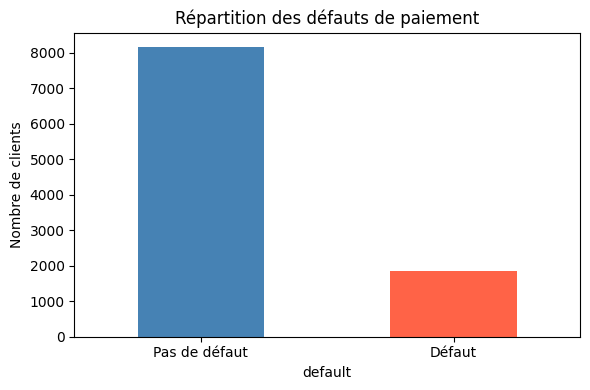

In [3]:
# Répartition des défauts
plt.figure(figsize=(6,4))
df['default'].value_counts().plot(kind='bar', color=['steelblue', 'tomato'])
plt.title("Répartition des défauts de paiement")
plt.xticks([0, 1], ['Pas de défaut', 'Défaut'], rotation=0)
plt.ylabel("Nombre de clients")
plt.tight_layout()
plt.show()


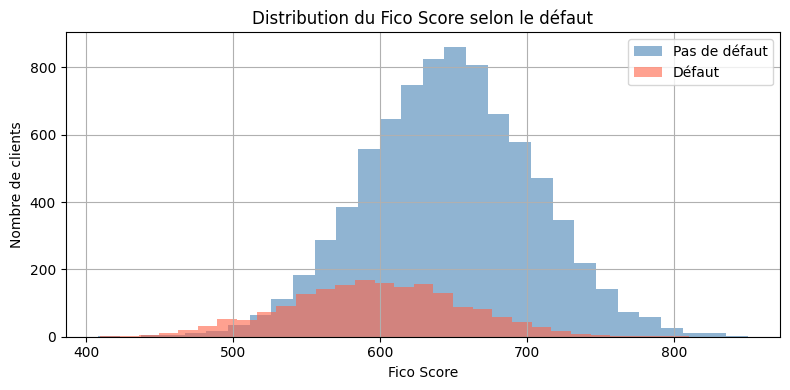

In [4]:
# Distribution du fico_score selon le défaut
plt.figure(figsize=(8,4))
df[df['default']==0]['fico_score'].hist(alpha=0.6, label='Pas de défaut', color='steelblue', bins=30)
df[df['default']==1]['fico_score'].hist(alpha=0.6, label='Défaut', color='tomato', bins=30)
plt.title("Distribution du Fico Score selon le défaut")
plt.xlabel("Fico Score")
plt.ylabel("Nombre de clients")
plt.legend()
plt.tight_layout()
plt.show()

Observation : Les clients en défaut (rouge) ont tendance à avoir un fico score un peu plus bas. C'est logique : un mauvais score de crédit = plus de risque de défaut

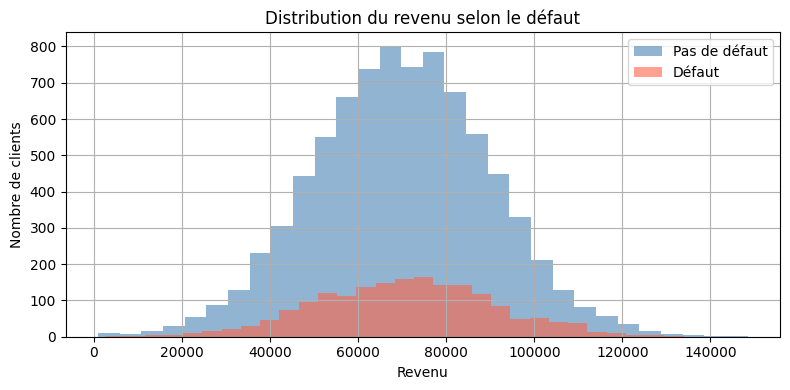

In [5]:
# Revenu selon le défaut
plt.figure(figsize=(8,4))
df[df['default']==0]['income'].hist(alpha=0.6, label='Pas de défaut', color='steelblue', bins=30)
df[df['default']==1]['income'].hist(alpha=0.6, label='Défaut', color='tomato', bins=30)
plt.title("Distribution du revenu selon le défaut")
plt.xlabel("Revenu")
plt.ylabel("Nombre de clients")
plt.legend()
plt.tight_layout()
plt.show()


Observations : Les revenus des clients en défaut et sans défaut sont similaires, le revenu seul n'est pas très utile pour prédire un défaut.

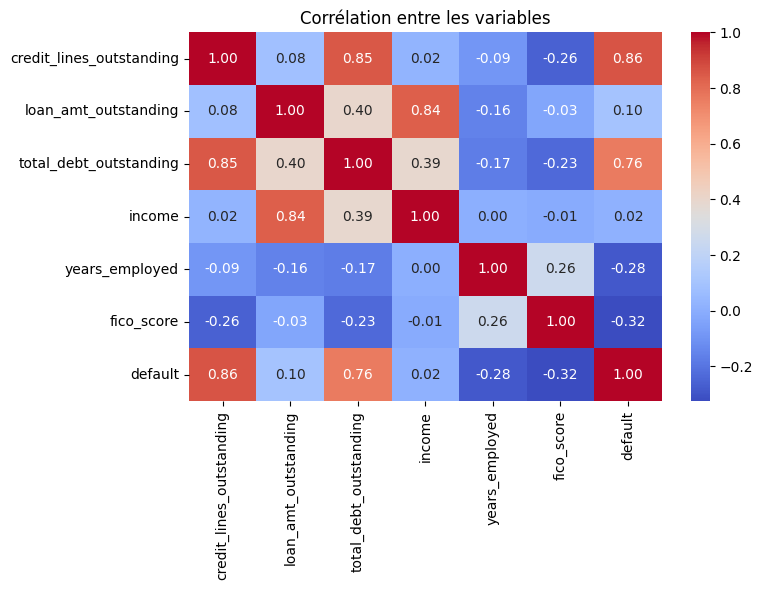

In [6]:
# Corrélation entre toutes les variables
plt.figure(figsize=(8,6))
sns.heatmap(df.drop('customer_id', axis=1).corr(), annot=True, fmt=".2f", cmap="coolwarm")
plt.title("Corrélation entre les variables")
plt.tight_layout()
plt.show()

Observation : Les variables les plus liées au défaut sont credit_lines_outstanding (Plus de crédits = plus de risque), total_debt_outstanding (Plus de dettes = plus de risque), fico_score (Plus le score est bas = plus de risque)

## **Nettoyage et préparation des données**

In [8]:
# Suppression de la colonne inutile customer_id
df_clean = df.drop('customer_id', axis=1)

# Séparation des variables explicatives (X) et de la cible (y)
X = df_clean.drop('default', axis=1)
y = df_clean['default']

# Normalisation des données
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Sauvegarde du dataset clean
df_clean.to_csv("Loan_Data_clean.csv", index=False)

print("Dataset clean sauvegardé ")
print("Variables utilisées :", list(X.columns))
print("Taille du dataset :", X_scaled.shape)

Dataset clean sauvegardé 
Variables utilisées : ['credit_lines_outstanding', 'loan_amt_outstanding', 'total_debt_outstanding', 'income', 'years_employed', 'fico_score']
Taille du dataset : (10000, 6)


In [9]:
# Afficher les données nettoyées
print("Aperçu des données prêtes pour la modélisation :")
pd.DataFrame(X_scaled, columns=X.columns).head()

Aperçu des données prêtes pour la modélisation :


,credit_lines_outstanding,loan_amt_outstanding,total_debt_outstanding,income,years_employed,fico_score
0,-0.837960,0.747096,-0.724848,0.398555,0.285425,-0.536770
1,2.029409,-1.548375,-0.073967,-2.161876,-1.629325,-1.080832
2,-0.837960,-0.560509,-1.009696,-0.207919,-0.352825,-0.586230
3,-0.837960,0.427045,-0.938184,0.215083,0.285425,-0.421363
4,-0.264486,-1.979733,-1.048780,-2.321314,0.923675,-0.108115


In [11]:
import numpy as np
from google.colab import files

# Sauvegarde de X et y
np.save("X_scaled.npy", X_scaled)
np.save("y.npy", y.values)
df_clean.to_csv("Loan_Data_clean.csv", index=False)

# Téléchargement sur ton ordi
files.download("Loan_Data_clean.csv")
files.download("X_scaled.npy")
files.download("y.npy")

print("✅ Fichiers téléchargés !")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

✅ Fichiers téléchargés !
